In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

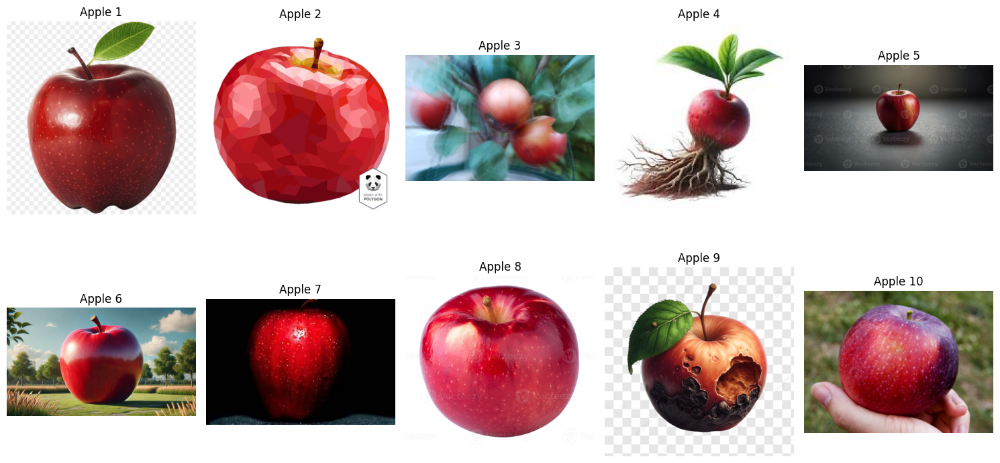

In [4]:
from PIL import Image
import matplotlib.pyplot as plt

image_paths = [
    "/content/apple1.png",
    "/content/apple10.jpg.jpeg",
    "/content/apple2.jpg.jpeg",
    "/content/apple3.jpeg",
    "/content/apple4.jpg.jpeg",
    "/content/apple5.jpg.jpeg",
    "/content/apple6.jpeg",
    "/content/apple7.jpg.jpeg",
    "/content/apple8.png",
    "/content/apple9.avif"
]

plt.figure(figsize=(15, 8))

for i, path in enumerate(image_paths):
    img = Image.open(path)

    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(f"Apple {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
resized_images = []

for path in image_paths:
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    resized = cv2.resize(img, (128, 128))
    resized_images.append(resized)

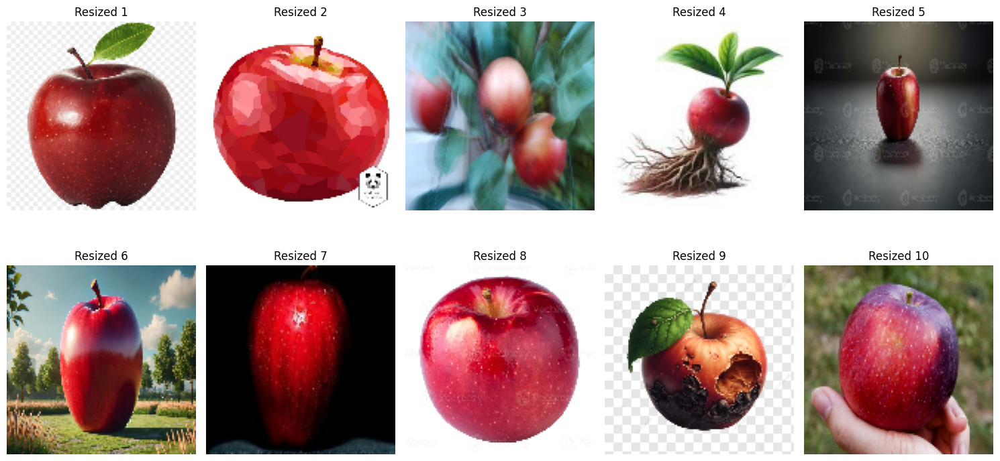

In [6]:
plt.figure(figsize=(15, 8))

for i, img in enumerate(resized_images):
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(f"Resized {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [7]:
normalized_images = []

for img in resized_images:
    normalized = img.astype("float32") / 255.0
    normalized_images.append(normalized)

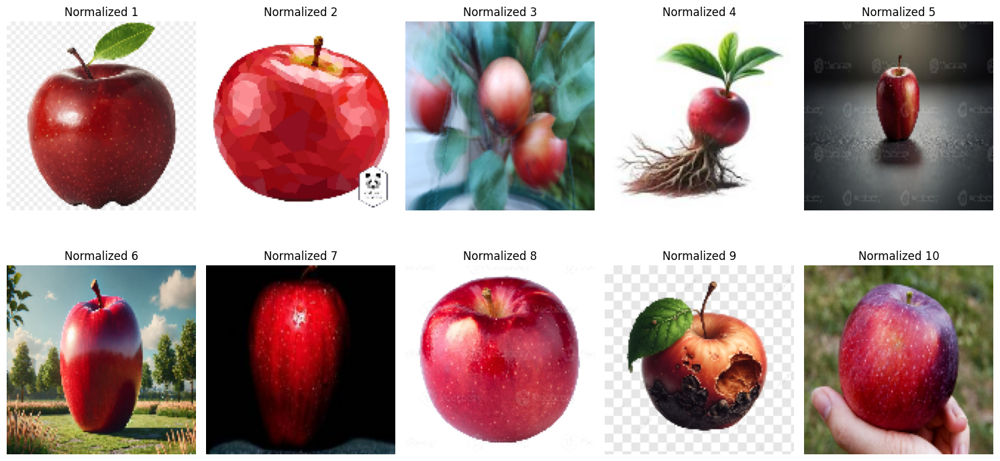

In [8]:
plt.figure(figsize=(15, 8))

for i, img in enumerate(normalized_images):
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(f"Normalized {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [9]:
print("Minimum pixel value:", normalized_images[0].min())
print("Maximum pixel value:", normalized_images[0].max())

Minimum pixel value: 0.023529412
Maximum pixel value: 0.99607843


In [10]:
X = np.array(normalized_images)

print("Dataset shape:", X.shape)

Dataset shape: (10, 128, 128, 3)


In [11]:
import os
from PIL import Image

output_folder = "/content/preprocessed_apples"
os.makedirs(output_folder, exist_ok=True)

for i, img in enumerate(normalized_images):
    # Convert 0-1 values back to 0-255 for saving
    output_img = (img * 255).astype("uint8")

    Image.fromarray(output_img).save(
        f"{output_folder}/apple{i+1}_preprocessed.png"
    )

print("All 10 preprocessed images saved successfully!")

All 10 preprocessed images saved successfully!


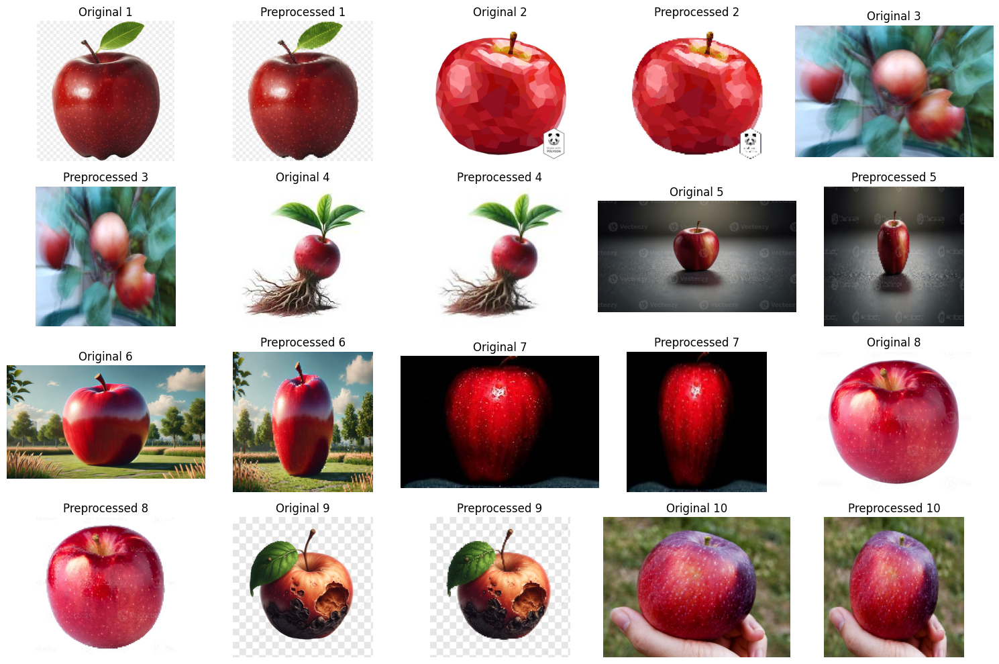

In [12]:
plt.figure(figsize=(15, 10))

for i in range(10):
    original = Image.open(image_paths[i]).convert("RGB")

    plt.subplot(4, 5, 2*i + 1)
    plt.imshow(original)
    plt.title(f"Original {i+1}")
    plt.axis("off")

    plt.subplot(4, 5, 2*i + 2)
    plt.imshow(normalized_images[i])
    plt.title(f"Preprocessed {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
preprocessed_images = []

for path in image_paths:
    img = cv2.imread(path)

    # Convert BGR to RGB
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Resize
    img = cv2.resize(img, (128, 128))

    # Reduce noise
    img = cv2.fastNlMeansDenoisingColored(
        img, None, 10, 10, 7, 21
    )

    # Slight smoothing
    img = cv2.GaussianBlur(img, (3, 3), 0)

    # Normalize
    img = img.astype("float32") / 255.0

    preprocessed_images.append(img)

print("Preprocessing completed for all 10 images!")

Preprocessing completed for all 10 images!


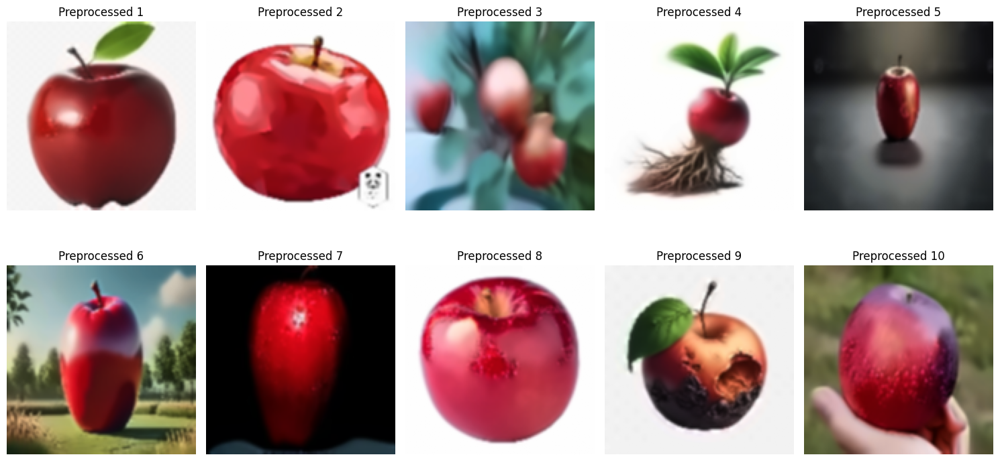

In [14]:
plt.figure(figsize=(15, 8))

for i, img in enumerate(preprocessed_images):
    plt.subplot(2, 5, i + 1)
    plt.imshow(img)
    plt.title(f"Preprocessed {i + 1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

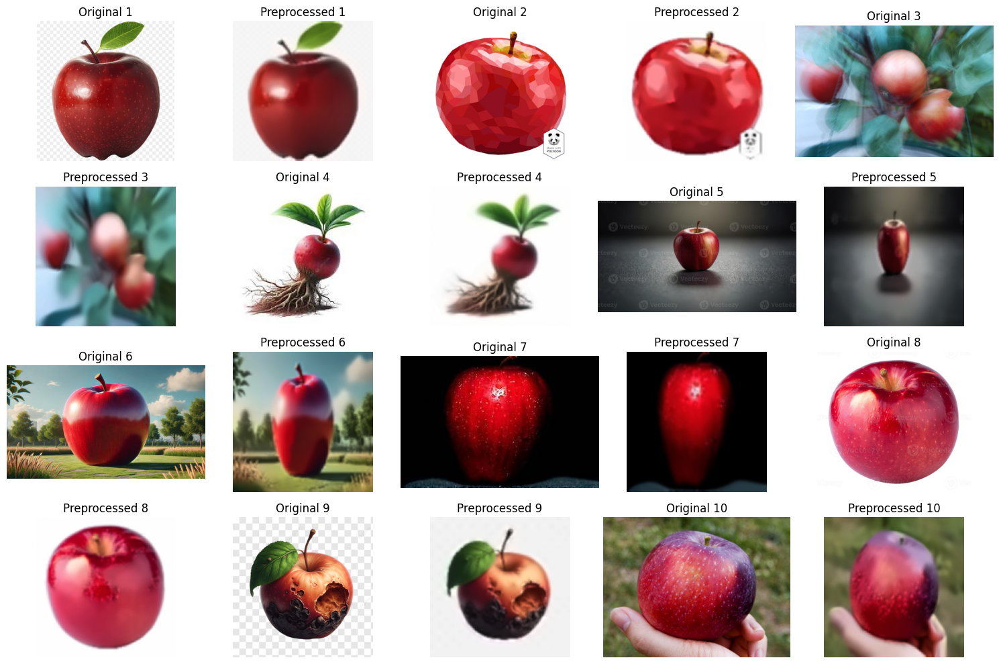

In [15]:
plt.figure(figsize=(15, 10))

for i in range(10):
    original = Image.open(image_paths[i]).convert("RGB")

    plt.subplot(4, 5, 2*i + 1)
    plt.imshow(original)
    plt.title(f"Original {i+1}")
    plt.axis("off")

    plt.subplot(4, 5, 2*i + 2)
    plt.imshow(preprocessed_images[i])
    plt.title(f"Preprocessed {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [16]:
X = np.array(preprocessed_images)

print("Dataset shape:", X.shape)
print("Data type:", X.dtype)
print("Minimum value:", X.min())
print("Maximum value:", X.max())

Dataset shape: (10, 128, 128, 3)
Data type: float32
Minimum value: 0.0
Maximum value: 0.99607843


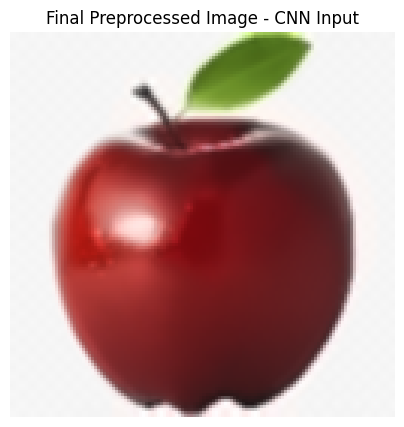

In [17]:
plt.figure(figsize=(5, 5))

plt.imshow(X[0])
plt.title("Final Preprocessed Image - CNN Input")
plt.axis("off")
plt.show()plt.figure(figsize=(15, 8))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[i])
    plt.title(f"Final Image {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

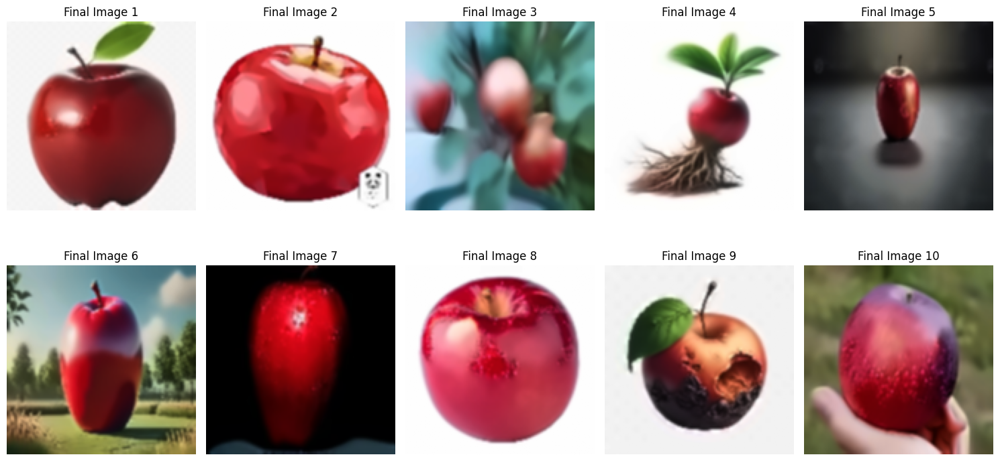

In [18]:
plt.figure(figsize=(15, 8))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X[i])
    plt.title(f"Final Image {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()

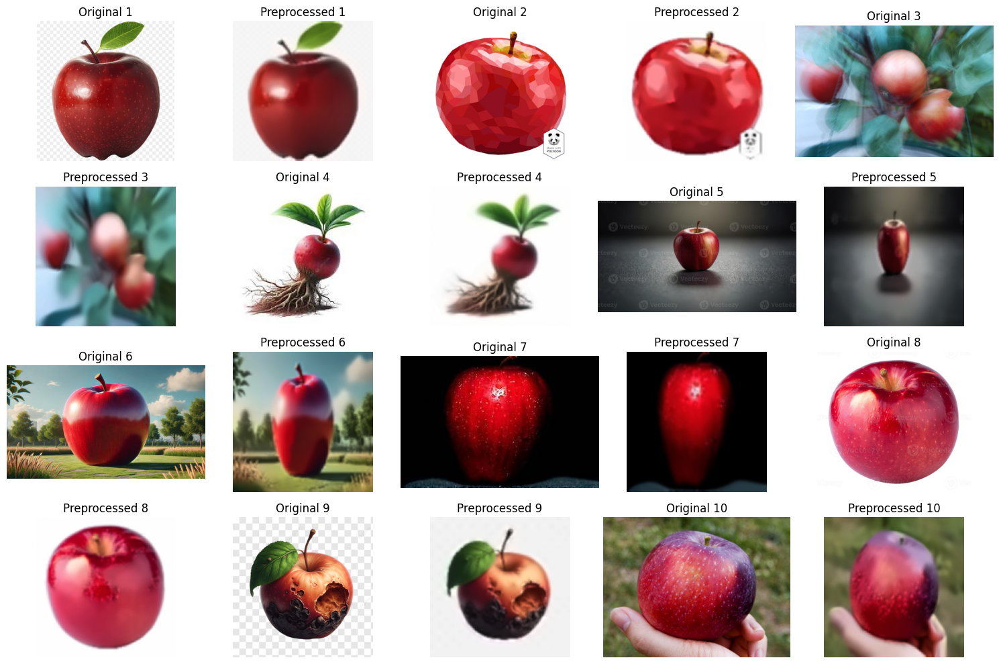

In [19]:
plt.figure(figsize=(15, 10))

for i in range(10):

    # Original image
    original = Image.open(image_paths[i]).convert("RGB")

    plt.subplot(4, 5, 2*i + 1)
    plt.imshow(original)
    plt.title(f"Original {i+1}")
    plt.axis("off")

    # Preprocessed image
    plt.subplot(4, 5, 2*i + 2)
    plt.imshow(X[i])
    plt.title(f"Preprocessed {i+1}")
    plt.axis("off")

plt.tight_layout()
plt.show()